# Basic ML Hand Mapping: MediaPipe Tasks -> Inspire RH56

This notebook trains a regression network that maps MediaPipe Hands landmarks to RH56 actuator targets.

Pipeline:
1. Load pose labels from `pose_actuator_labels.csv`
2. Extract landmarks from videos in `training_videos/<pose_name>/*.mp4`
3. Cache extracted frame-level data (`extracted_dataset.npz`)
4. Train and save a PyTorch MLP model (`hand_to_actuator_mlp.pt`)
5. Load model if it already exists
6. Run inference on videos in `test_videos/` and save per-frame DOF sequences

DOF output order is always:
`[little, ring, middle, index, thumb_bend, thumb_rotation]`

In [4]:
%pip install -q mediapipe opencv-python numpy pandas torch matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [41]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Paths
ROOT = Path('.')
LABEL_CSV = ROOT / 'pose_actuator_labels.csv'
TRAINING_DIR = ROOT / 'training_videos'
TEST_DIR = ROOT / 'test_videos'
CACHE_FILE = ROOT / 'extracted_dataset.npz'
CACHE_MANIFEST = ROOT / 'extracted_dataset_manifest.csv'
MODEL_FILE = ROOT / 'hand_to_actuator_mlp.pt'
INFERENCE_DIR = ROOT / 'inference_outputs'

# Search for a hand_landmarker.task model without leaving this project workspace.
TASK_MODEL_CANDIDATES = [
    ROOT / 'hand_landmarker.task',
    ROOT / '../static_hand_mappings/hand_landmarker.task',
    ROOT / '../dynamic_hand_mappings/hand_landmarker.task',
]
HAND_LANDMARKER_TASK = next((p.resolve() for p in TASK_MODEL_CANDIDATES if p.exists()), None)

DOF_COLUMNS = ['little', 'ring', 'middle', 'index', 'thumb_bend', 'thumb_rotation']

# Extraction/training config
MAX_FRAMES_PER_VIDEO = 1000
FRAME_STRIDE = 1
MIN_DETECTION_CONF = 0.6
MIN_TRACKING_CONF = 0.5

BATCH_SIZE = 128
EPOCHS = 160
LEARNING_RATE = 5e-4
HIDDEN_DIM = 320
DROPOUT = 0.15
WEIGHT_DECAY = 1e-4

FORCE_RETRAIN = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')
print(f'Label CSV: {LABEL_CSV.resolve()}')
print(f'Training dir: {TRAINING_DIR.resolve()}')
print(f'Test dir: {TEST_DIR.resolve()}')
print(f'Found hand_landmarker.task: {HAND_LANDMARKER_TASK}')

Using device: cpu
Label CSV: /home/katelyn/research-inspire_hand_mirroring/basic_ml_hand_mappings/pose_actuator_labels.csv
Training dir: /home/katelyn/research-inspire_hand_mirroring/basic_ml_hand_mappings/training_videos
Test dir: /home/katelyn/research-inspire_hand_mirroring/basic_ml_hand_mappings/test_videos
Found hand_landmarker.task: /home/katelyn/research-inspire_hand_mirroring/static_hand_mappings/hand_landmarker.task


In [42]:
if HAND_LANDMARKER_TASK is None:
    raise FileNotFoundError(
        'hand_landmarker.task was not found. Place it in basic_ml_hand_mappings/ or keep static/dynamic folders present.'
    )

if not LABEL_CSV.exists():
    raise FileNotFoundError(f'Missing label CSV: {LABEL_CSV}')

if not TRAINING_DIR.exists():
    raise FileNotFoundError(f'Missing training directory: {TRAINING_DIR}')

label_df = pd.read_csv(LABEL_CSV)
required_cols = {'pose_name', *DOF_COLUMNS}
missing = required_cols.difference(label_df.columns)
if missing:
    raise ValueError(f'Label CSV missing columns: {sorted(missing)}')

label_df['pose_name'] = label_df['pose_name'].astype(str)
pose_to_target: Dict[str, np.ndarray] = {
    row['pose_name']: row[DOF_COLUMNS].to_numpy(dtype=np.float32)
    for _, row in label_df.iterrows()
}

print(f'Loaded {len(pose_to_target)} labeled poses from CSV')
label_df.head()

Loaded 10 labeled poses from CSV


,pose_name,description,little,ring,middle,index,thumb_bend,thumb_rotation
0,open_hand,Fingers spread and straight,1000,1000,1000,1000,1000,1000
1,fist,Closed fist,0,0,0,0,220,350
2,point_index,Index finger extended,0,0,0,1000,220,350
3,peace_sign,Index and middle extended,0,0,1000,1000,220,350
4,three_fingers,Index middle and ring extended,0,1000,1000,1000,220,350


In [43]:
@dataclass
class ExtractionResult:
    frame_features: np.ndarray
    frame_indices: np.ndarray


def build_hand_landmarker(task_path: Path):
    base_options = mp.tasks.BaseOptions(model_asset_path=str(task_path))
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_hands=1,
        min_hand_detection_confidence=MIN_DETECTION_CONF,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=MIN_TRACKING_CONF,
    )
    return mp.tasks.vision.HandLandmarker.create_from_options(options)


def extract_video_features(
    video_path: Path,
    landmarker,
    max_frames: int = MAX_FRAMES_PER_VIDEO,
    frame_stride: int = FRAME_STRIDE,
) -> ExtractionResult:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Could not open video: {video_path}')

    fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)
    if not np.isfinite(fps) or fps <= 0:
        fps = 30.0
    frame_id = 0
    kept = 0
    prev_ts_ms = -1
    features: List[np.ndarray] = []
    frame_indices: List[int] = []

    while kept < max_frames:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_id % frame_stride != 0:
            frame_id += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        ts_ms = int((frame_id / fps) * 1000.0)
        if ts_ms <= prev_ts_ms:
            ts_ms = prev_ts_ms + 1
        prev_ts_ms = ts_ms
        result = landmarker.detect_for_video(mp_img, ts_ms)

        lm_arr = None
        if result.hand_world_landmarks:
            lm = result.hand_world_landmarks[0]
            lm_arr = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)
        elif result.hand_landmarks:
            lm = result.hand_landmarks[0]
            lm_arr = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)

        if lm_arr is not None:
            features.append(lm_arr.reshape(-1))
            frame_indices.append(frame_id)
            kept += 1

        frame_id += 1

    cap.release()

    if not features:
        return ExtractionResult(
            frame_features=np.empty((0, 63), dtype=np.float32),
            frame_indices=np.empty((0,), dtype=np.int32),
        )

    return ExtractionResult(
        frame_features=np.stack(features).astype(np.float32),
        frame_indices=np.array(frame_indices, dtype=np.int32),
    )


def find_training_videos(training_root: Path) -> List[Tuple[str, Path]]:
    exts = {'.mp4', '.mov', '.avi', '.mkv'}
    found: List[Tuple[str, Path]] = []

    # Preferred layout: training_videos/<pose_name>/*.mp4
    for pose_dir in sorted([p for p in training_root.iterdir() if p.is_dir()]):
        pose_name = pose_dir.name
        for video in sorted(pose_dir.rglob('*')):
            if video.suffix.lower() in exts:
                found.append((pose_name, video))

    # Fallback: flat files where prefix before first underscore is pose name.
    if not found:
        for video in sorted(training_root.rglob('*')):
            if video.suffix.lower() not in exts:
                continue
            pose_name = video.stem.split('_')[0]
            found.append((pose_name, video))

    return found

In [44]:
def build_or_load_dataset(
    use_cache: bool = True,
    force_reextract: bool = False,
):
    if use_cache and CACHE_FILE.exists() and not force_reextract:
        data = np.load(CACHE_FILE, allow_pickle=True)
        X = data['X'].astype(np.float32)
        y = data['y'].astype(np.float32)
        video_ids = data['video_ids'].astype(np.int32)
        print(f'Loaded cached dataset: X={X.shape}, y={y.shape}')
        if CACHE_MANIFEST.exists():
            manifest_df = pd.read_csv(CACHE_MANIFEST)
        else:
            manifest_df = pd.DataFrame()
        return X, y, video_ids, manifest_df

    train_items = find_training_videos(TRAINING_DIR)
    if not train_items:
        raise FileNotFoundError(
            f'No training videos found in {TRAINING_DIR}. '
            'Use training_videos/<pose_name>/<clip>.mp4.'
        )

    unknown_poses = sorted({pose for pose, _ in train_items if pose not in pose_to_target})
    if unknown_poses:
        raise ValueError(
            'Videos found with pose names missing in pose_actuator_labels.csv: '
            + ', '.join(unknown_poses)
        )

    X_rows: List[np.ndarray] = []
    y_rows: List[np.ndarray] = []
    video_id_rows: List[int] = []
    manifest_records: List[dict] = []

    for vid, (pose_name, video_path) in enumerate(tqdm(train_items, desc='Extracting training data')):
        with build_hand_landmarker(HAND_LANDMARKER_TASK) as landmarker:
            result = extract_video_features(video_path, landmarker)
            if result.frame_features.shape[0] == 0:
                print(f'Warning: no hand detected in {video_path}; skipping')
                continue

            targets = np.repeat(
                pose_to_target[pose_name][None, :],
                repeats=result.frame_features.shape[0],
                axis=0,
            ).astype(np.float32)

            X_rows.append(result.frame_features)
            y_rows.append(targets)
            video_id_rows.append(np.full((result.frame_features.shape[0],), vid, dtype=np.int32))

            for frame_idx in result.frame_indices.tolist():
                manifest_records.append({
                    'video_id': vid,
                    'pose_name': pose_name,
                    'video_path': str(video_path),
                    'frame_index': frame_idx,
                })

    if not X_rows:
        raise RuntimeError('Extraction finished but no frames were detected.')

    X = np.concatenate(X_rows, axis=0).astype(np.float32)
    y = np.concatenate(y_rows, axis=0).astype(np.float32)
    video_ids = np.concatenate(video_id_rows, axis=0).astype(np.int32)

    np.savez_compressed(CACHE_FILE, X=X, y=y, video_ids=video_ids)
    manifest_df = pd.DataFrame.from_records(manifest_records)
    manifest_df.to_csv(CACHE_MANIFEST, index=False)

    print(f'Saved cache to {CACHE_FILE}')
    print(f'Saved manifest to {CACHE_MANIFEST}')
    print(f'X={X.shape}, y={y.shape}, unique videos={len(np.unique(video_ids))}')
    return X, y, video_ids, manifest_df


X, y, video_ids, manifest_df = build_or_load_dataset(use_cache=True, force_reextract=False)
print(manifest_df.head())

Loaded cached dataset: X=(3073, 63), y=(3073, 6)
   video_id pose_name                       video_path  frame_index
0         0      fist  training_videos/fist/0_fist.mp4            0
1         0      fist  training_videos/fist/0_fist.mp4            2
2         0      fist  training_videos/fist/0_fist.mp4            4
3         0      fist  training_videos/fist/0_fist.mp4            6
4         0      fist  training_videos/fist/0_fist.mp4            8


In [45]:
class HandToActuatorMLP(nn.Module):
    def __init__(
        self,
        in_dim: int = 63,
        out_dim: int = 6,
        hidden_dim: int = HIDDEN_DIM,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def split_by_video(video_ids: np.ndarray, val_fraction: float = 0.2, seed: int = 42):
    unique = np.unique(video_ids)
    rng = np.random.default_rng(seed)
    rng.shuffle(unique)
    n_val = max(1, int(len(unique) * val_fraction))
    val_videos = set(unique[:n_val].tolist())

    val_mask = np.array([vid in val_videos for vid in video_ids], dtype=bool)
    train_mask = ~val_mask
    return train_mask, val_mask


def make_loader(X_np: np.ndarray, y_np: np.ndarray, batch_size: int, shuffle: bool):
    x_t = torch.from_numpy(X_np).float()
    y_t = torch.from_numpy(y_np).float()
    return DataLoader(TensorDataset(x_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_model(
    X: np.ndarray,
    y: np.ndarray,
    video_ids: np.ndarray,
    batch_size: int = BATCH_SIZE,
    epochs: int = EPOCHS,
    learning_rate: float = LEARNING_RATE,
    hidden_dim: int = HIDDEN_DIM,
    dropout: float = DROPOUT,
    weight_decay: float = WEIGHT_DECAY,
):
    train_mask, val_mask = split_by_video(video_ids, val_fraction=0.2, seed=42)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]

    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True) + 1e-6
    X_train_n = (X_train - x_mean) / x_std
    X_val_n = (X_val - x_mean) / x_std

    y_mean = y_train.mean(axis=0, keepdims=True)
    y_std = y_train.std(axis=0, keepdims=True) + 1e-6
    y_train_n = (y_train - y_mean) / y_std
    y_val_n = (y_val - y_mean) / y_std

    train_loader = make_loader(X_train_n, y_train_n, batch_size, shuffle=True)
    val_loader = make_loader(X_val_n, y_val_n, batch_size, shuffle=False)

    model = HandToActuatorMLP(
        in_dim=X.shape[1],
        out_dim=y.shape[1],
        hidden_dim=hidden_dim,
        dropout=dropout,
    ).to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optim, mode='min', factor=0.5, patience=8, min_lr=1e-6
    )
    loss_fn = nn.SmoothL1Loss(beta=0.2)
    print(
        f'Training config | epochs={epochs}, batch_size={batch_size}, '
        f'lr={learning_rate}, hidden_dim={hidden_dim}, dropout={dropout}, wd={weight_decay}'
    )

    best_val = float('inf')
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optim.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optim.step()
            train_losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            val_losses = []
            val_mae_raw = []
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                val_losses.append(float(loss_fn(pred, yb).item()))

                pred_real = pred.cpu().numpy() * y_std + y_mean
                yb_real = yb.cpu().numpy() * y_std + y_mean
                val_mae_raw.append(float(np.mean(np.abs(pred_real - yb_real))))

        mean_train = float(np.mean(train_losses)) if train_losses else float('nan')
        mean_val = float(np.mean(val_losses)) if val_losses else float('nan')
        mean_val_mae = float(np.mean(val_mae_raw)) if val_mae_raw else float('nan')

        if mean_val < best_val:
            best_val = mean_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step(mean_val)

        if ep == 1 or ep % 10 == 0 or ep == epochs:
            lr_now = optim.param_groups[0]['lr']
            print(
                f'Epoch {ep:03d} | train_loss={mean_train:.4f} | val_loss={mean_val:.4f} '
                f'| val_mae_raw={mean_val_mae:.2f} | lr={lr_now:.2e}'
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    checkpoint = {
        'state_dict': model.state_dict(),
        'x_mean': x_mean.astype(np.float32),
        'x_std': x_std.astype(np.float32),
        'y_mean': y_mean.astype(np.float32),
        'y_std': y_std.astype(np.float32),
        'input_dim': int(X.shape[1]),
        'output_dim': int(y.shape[1]),
        'dof_columns': DOF_COLUMNS,
        'training_config': {
            'batch_size': int(batch_size),
            'epochs': int(epochs),
            'learning_rate': float(learning_rate),
            'hidden_dim': int(hidden_dim),
            'dropout': float(dropout),
            'weight_decay': float(weight_decay),
        },
    }
    torch.save(checkpoint, MODEL_FILE)
    print(f'Saved model to {MODEL_FILE}')
    return (
        model,
        x_mean.astype(np.float32),
        x_std.astype(np.float32),
        y_mean.astype(np.float32),
        y_std.astype(np.float32),
    )


def load_model(model_path: Path):
    ckpt = torch.load(model_path, map_location='cpu', weights_only=False)
    train_cfg = ckpt.get('training_config', {})
    model = HandToActuatorMLP(
        in_dim=int(ckpt.get('input_dim', 63)),
        out_dim=int(ckpt.get('output_dim', 6)),
        hidden_dim=int(train_cfg.get('hidden_dim', HIDDEN_DIM)),
        dropout=float(train_cfg.get('dropout', DROPOUT)),
    )
    model.load_state_dict(ckpt['state_dict'])
    model.to(DEVICE).eval()
    x_mean = np.asarray(ckpt['x_mean'], dtype=np.float32)
    x_std = np.asarray(ckpt['x_std'], dtype=np.float32)
    y_mean = np.asarray(
        ckpt.get('y_mean', np.zeros((1, int(ckpt.get('output_dim', 6))), dtype=np.float32)),
        dtype=np.float32,
    )
    y_std = np.asarray(
        ckpt.get('y_std', np.ones((1, int(ckpt.get('output_dim', 6))), dtype=np.float32)),
        dtype=np.float32,
    )
    return model, x_mean, x_std, y_mean, y_std


if FORCE_RETRAIN or not MODEL_FILE.exists():
    if FORCE_RETRAIN and MODEL_FILE.exists():
        print(f'Force retrain enabled. Overwriting: {MODEL_FILE}')
    else:
        print('Training a new model...')
    model, x_mean, x_std, y_mean, y_std = train_model(
        X,
        y,
        video_ids,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        weight_decay=WEIGHT_DECAY,
    )
else:
    print(f'Loading existing model: {MODEL_FILE}')
    model, x_mean, x_std, y_mean, y_std = load_model(MODEL_FILE)

Force retrain enabled. Overwriting: hand_to_actuator_mlp.pt
Training config | epochs=160, batch_size=128, lr=0.0005, hidden_dim=320, dropout=0.15, wd=0.0001
Epoch 001 | train_loss=0.6810 | val_loss=0.7189 | val_mae_raw=312.77 | lr=5.00e-04
Epoch 010 | train_loss=0.1984 | val_loss=0.5349 | val_mae_raw=232.72 | lr=5.00e-04
Epoch 020 | train_loss=0.1373 | val_loss=0.4980 | val_mae_raw=219.03 | lr=5.00e-04
Epoch 030 | train_loss=0.1121 | val_loss=0.5020 | val_mae_raw=223.09 | lr=5.00e-04
Epoch 040 | train_loss=0.0985 | val_loss=0.5044 | val_mae_raw=223.38 | lr=5.00e-04
Epoch 050 | train_loss=0.0845 | val_loss=0.5195 | val_mae_raw=230.85 | lr=1.25e-04
Epoch 060 | train_loss=0.0819 | val_loss=0.5200 | val_mae_raw=232.02 | lr=6.25e-05
Epoch 070 | train_loss=0.0792 | val_loss=0.5137 | val_mae_raw=229.44 | lr=3.13e-05
Epoch 080 | train_loss=0.0802 | val_loss=0.5202 | val_mae_raw=232.02 | lr=1.56e-05
Epoch 090 | train_loss=0.0806 | val_loss=0.5193 | val_mae_raw=231.67 | lr=7.81e-06
Epoch 100 | t

In [46]:
def ema_smooth(arr: np.ndarray, alpha: float = 0.2) -> np.ndarray:
    if arr.shape[0] == 0:
        return arr
    out = arr.copy().astype(np.float32)
    for i in range(1, len(out)):
        out[i] = alpha * out[i] + (1.0 - alpha) * out[i - 1]
    return out


def predict_video_sequence(
    video_path: Path,
    model,
    x_mean: np.ndarray,
    x_std: np.ndarray,
    y_mean: np.ndarray,
    y_std: np.ndarray,
):
    with build_hand_landmarker(HAND_LANDMARKER_TASK) as landmarker:
        result = extract_video_features(
            video_path=video_path,
            landmarker=landmarker,
            max_frames=10_000,
            frame_stride=1,
        )

    if result.frame_features.shape[0] == 0:
        return result.frame_indices, np.empty((0, 6), dtype=np.float32)

    Xn = (result.frame_features - x_mean) / x_std
    xt = torch.from_numpy(Xn).float().to(DEVICE)

    with torch.no_grad():
        pred_n = model(xt).cpu().numpy().astype(np.float32)

    pred = pred_n * y_std + y_mean
    pred = np.clip(pred, 0.0, 1000.0)
    pred = ema_smooth(pred, alpha=0.2)
    return result.frame_indices, pred


INFERENCE_DIR.mkdir(parents=True, exist_ok=True)
exts = {'.mp4', '.mov', '.avi', '.mkv'}
test_videos = [p for p in sorted(TEST_DIR.rglob('*')) if p.suffix.lower() in exts]

if not test_videos:
    print(f'No videos found in {TEST_DIR}. Add clips and rerun this cell.')
else:
    summary_records = []
    for video_path in tqdm(test_videos, desc='Inference on test videos'):
        frame_idx, pred_seq = predict_video_sequence(video_path, model, x_mean, x_std, y_mean, y_std)

        out_base = INFERENCE_DIR / video_path.stem
        npy_path = out_base.with_name(f'{out_base.name}_dof_sequence.npy')
        csv_path = out_base.with_name(f'{out_base.name}_dof_sequence.csv')

        np.save(npy_path, pred_seq.astype(np.float32))

        if pred_seq.shape[0] > 0:
            out_df = pd.DataFrame(pred_seq, columns=DOF_COLUMNS)
            out_df.insert(0, 'frame_index', frame_idx[: len(out_df)])
            out_df.to_csv(csv_path, index=False)
            mean_pose = pred_seq.mean(axis=0)
        else:
            pd.DataFrame(columns=['frame_index', *DOF_COLUMNS]).to_csv(csv_path, index=False)
            mean_pose = np.full((6,), np.nan, dtype=np.float32)

        summary_records.append({
            'video_path': str(video_path),
            'frames_predicted': int(pred_seq.shape[0]),
            'output_npy': str(npy_path),
            'output_csv': str(csv_path),
            **{f'mean_{k}': float(v) if np.isfinite(v) else np.nan for k, v in zip(DOF_COLUMNS, mean_pose)},
        })

    summary_df = pd.DataFrame(summary_records)
    summary_path = INFERENCE_DIR / 'inference_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f'Saved inference summary: {summary_path}')
    display(summary_df.head())

Inference on test videos:   0%|          | 0/4 [00:00<?, ?it/s]I0000 00:00:1777758969.134103   37336 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777758969.183303   37353 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1777758969.338279   37349 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777758969.368466   37342 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Inference on test videos:  25%|██▌       | 1/4 [00:03<00:11,  3.76s/it]I0000 00:00:1777758972.851567   37397 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777758972.858673   37414 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), ren

Saved inference summary: inference_outputs/inference_summary.csv


,video_path,frames_predicted,output_npy,output_csv,mean_little,mean_ring,mean_middle,mean_index,mean_thumb_bend,mean_thumb_rotation
0,test_videos/0_test.mp4,257,inference_outputs/0_test_dof_sequence.npy,inference_outputs/0_test_dof_sequence.csv,274.093536,403.127350,409.892334,605.660278,754.626587,966.485840
1,test_videos/1_test.mp4,224,inference_outputs/1_test_dof_sequence.npy,inference_outputs/1_test_dof_sequence.csv,118.347557,405.743988,398.040558,666.642761,319.798889,900.296082
2,test_videos/2_test.mp4,174,inference_outputs/2_test_dof_sequence.npy,inference_outputs/2_test_dof_sequence.csv,549.258240,560.323181,556.393494,411.105927,419.231049,791.943054
3,test_videos/3_test.mp4,169,inference_outputs/3_test_dof_sequence.npy,inference_outputs/3_test_dof_sequence.csv,521.392700,755.205139,760.296082,649.048828,175.064606,796.896362


## Usage Notes

1. Put recordings in `training_videos/<pose_name>/`.
2. Ensure each `<pose_name>` exists in `pose_actuator_labels.csv`.
3. Re-run extraction with `force_reextract=True` after adding new training clips.
4. Put evaluation clips in `test_videos/` and run the inference cell.
5. Outputs are saved under `inference_outputs/` as both `.npy` and `.csv`.

## Phase 7 - Collision-Safe Sequence + Hardware Replay

These cells mirror the dynamic notebook workflow for post-processing and robot output:

1. Load one predicted sequence from `inference_outputs/`.
2. Apply hard clamp + collision rules + temporal smoothing + deadband.
3. Plot the safe DOF position sequence.
4. Replay the sequence to RH56 hardware (or mock mode if serial/Modbus is unavailable).

In [76]:
import numpy as np
import pandas as pd

# Selection controls
SELECT_VIDEO_INDEX = 3
SEQUENCE_EMA_ALPHA = 0.30
SEQUENCE_MEDIAN_WINDOW = 5  # odd integer
SEQUENCE_DEADBAND = 5.0
POS_MIN, POS_MAX = 0.0, 1000.0

def load_predicted_sequence(summary_df: pd.DataFrame, video_index: int = 0) -> np.ndarray:
    if summary_df is None or summary_df.empty:
        raise ValueError('summary_df is empty. Run the inference cell first.')
    if video_index < 0 or video_index >= len(summary_df):
        raise IndexError(f'video_index={video_index} is out of range [0, {len(summary_df)-1}]')

    row = summary_df.iloc[video_index]
    npy_path = Path(row['output_npy'])
    if not npy_path.exists():
        raise FileNotFoundError(f'Predicted sequence not found: {npy_path}')

    seq = np.load(npy_path).astype(np.float32)
    if seq.ndim != 2 or seq.shape[1] != len(DOF_COLUMNS):
        raise ValueError(f'Unexpected sequence shape: {seq.shape}')

    print(f'Selected video: {row["video_path"]}')
    print(f'Loaded sequence: {npy_path} | shape={seq.shape}')
    return seq

pred_seq_raw = load_predicted_sequence(summary_df, video_index=SELECT_VIDEO_INDEX)

Selected video: test_videos/3_test.mp4
Loaded sequence: inference_outputs/3_test_dof_sequence.npy | shape=(169, 6)


In [77]:
def apply_hard_clamp_dense(arr: np.ndarray) -> np.ndarray:
    return np.clip(arr, POS_MIN, POS_MAX).astype(np.float32)

def apply_collision_rules_dense(arr: np.ndarray) -> np.ndarray:
    out = arr.copy()
    # RH56 thumb_bend index=4, thumb_rotation index=5, index finger index=3
    for i in range(len(out)):
        thumb_bend = float(out[i, 4])
        thumb_rot = float(out[i, 5])

        # Strong thumb closure can collide with index finger.
        if thumb_bend < 320.0:
            out[i, 3] = min(out[i, 3], 600.0)

        # Deep thumb adduction limits safe bend range.
        if thumb_rot < 900.0:
            out[i, 4] = min(out[i, 4], 450.0)
    return out.astype(np.float32)

def temporal_median_filter_dense(arr: np.ndarray, window: int = 5) -> np.ndarray:
    if window < 1 or window % 2 == 0:
        raise ValueError('window must be a positive odd integer')
    radius = window // 2
    out = arr.copy()
    for i in range(len(arr)):
        lo = max(0, i - radius)
        hi = min(len(arr), i + radius + 1)
        out[i] = np.median(arr[lo:hi], axis=0)
    return out.astype(np.float32)

def ema_smooth_dense(arr: np.ndarray, alpha: float = 0.15) -> np.ndarray:
    if len(arr) == 0:
        return arr
    out = arr.copy().astype(np.float32)
    for i in range(1, len(out)):
        out[i] = alpha * out[i] + (1.0 - alpha) * out[i - 1]
    return out

def apply_deadband_dense(arr: np.ndarray, threshold: float = 5.0) -> np.ndarray:
    if len(arr) == 0:
        return arr
    out = arr.copy().astype(np.float32)
    last = out[0].copy()
    for i in range(1, len(out)):
        out[i] = np.where(np.abs(out[i] - last) < threshold, last, out[i]).astype(np.float32)
        last = out[i].copy()
    return out

def build_safe_sequence(
    arr: np.ndarray,
    median_window: int = SEQUENCE_MEDIAN_WINDOW,
    ema_alpha: float = SEQUENCE_EMA_ALPHA,
    deadband: float = SEQUENCE_DEADBAND,
) -> np.ndarray:
    s0 = apply_hard_clamp_dense(arr)
    s1 = apply_collision_rules_dense(s0)
    s2 = temporal_median_filter_dense(s1, window=median_window)
    s3 = ema_smooth_dense(s2, alpha=ema_alpha)
    s4 = apply_deadband_dense(s3, threshold=deadband)
    return apply_hard_clamp_dense(s4)

pred_seq_safe = build_safe_sequence(pred_seq_raw)
print(f'Safe sequence shape: {pred_seq_safe.shape}')
print(f'Range check: min={pred_seq_safe.min():.0f}, max={pred_seq_safe.max():.0f}')

Safe sequence shape: (169, 6)
Range check: min=66, max=999


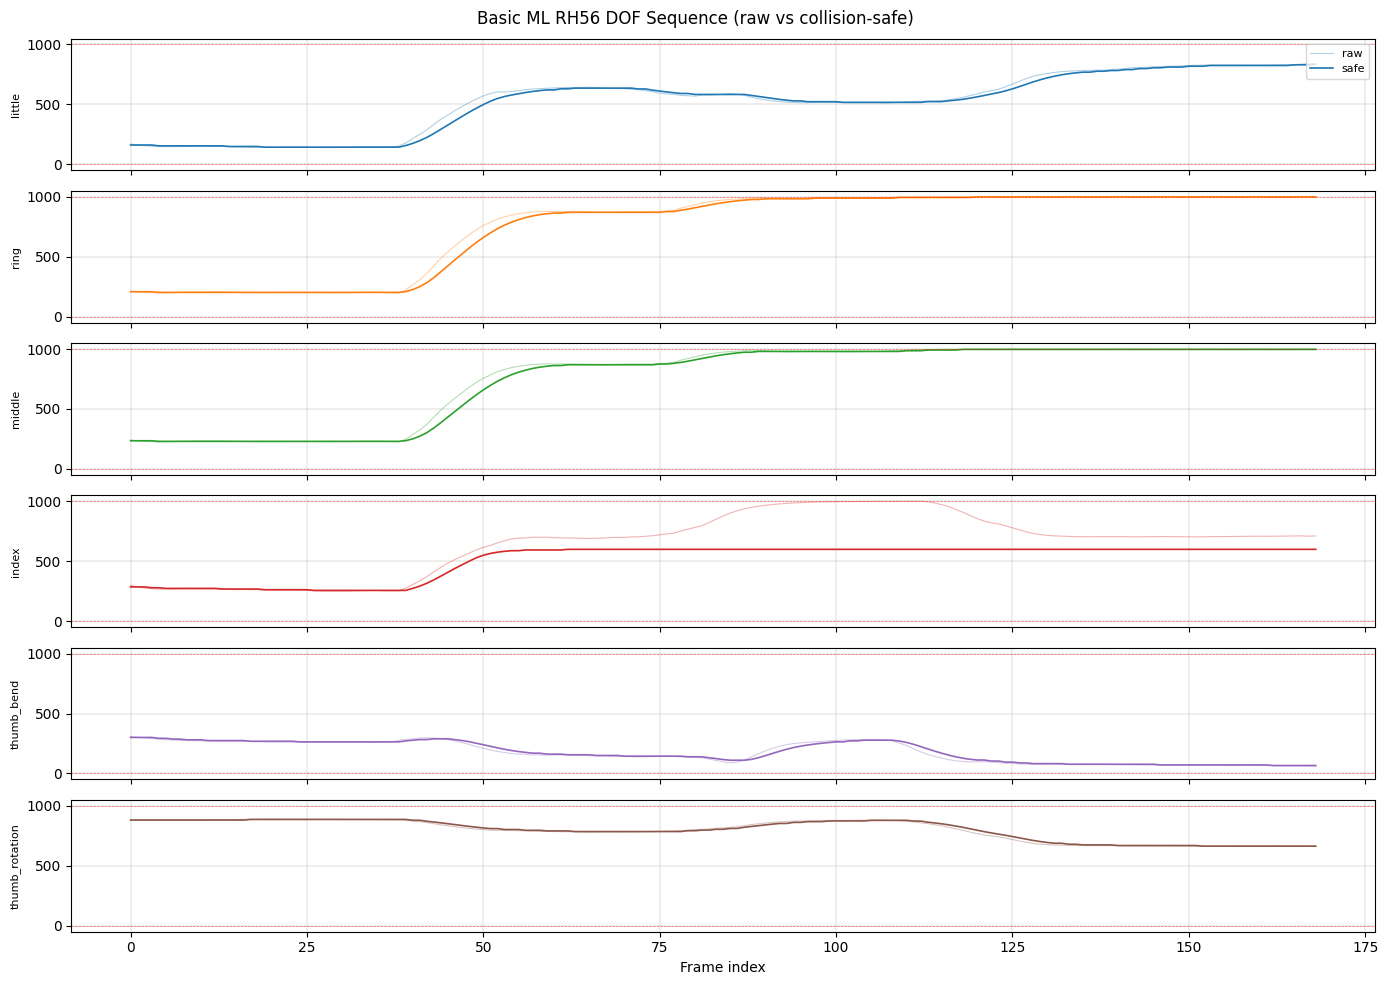


DOF                 min    max    mean     std
little              144    836   512.1   238.3
ring                203    999   743.4   333.7
middle              230    997   748.7   321.1
index               257    599   507.4   144.0
thumb_bend           66    300   179.7    83.1
thumb_rotation      664    886   800.0    82.6


In [78]:
import matplotlib.pyplot as plt

if pred_seq_safe.shape[0] == 0:
    print('No predicted frames to plot.')
else:
    frames = np.arange(pred_seq_safe.shape[0])
    fig, axes = plt.subplots(len(DOF_COLUMNS), 1, figsize=(14, 10), sharex=True)
    colors = plt.cm.tab10.colors

    for dof_idx, (ax, name) in enumerate(zip(axes, DOF_COLUMNS)):
        ax.plot(frames, pred_seq_raw[:, dof_idx], color=colors[dof_idx], lw=0.8, alpha=0.35, label='raw')
        ax.plot(frames, pred_seq_safe[:, dof_idx], color=colors[dof_idx], lw=1.2, label='safe')
        ax.set_ylabel(name, fontsize=8)
        ax.set_ylim(POS_MIN - 50, POS_MAX + 50)
        ax.axhline(POS_MIN, color='red', lw=0.5, linestyle='--', alpha=0.6)
        ax.axhline(POS_MAX, color='red', lw=0.5, linestyle='--', alpha=0.6)
        ax.grid(True, lw=0.3)
        if dof_idx == 0:
            ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Frame index')
    plt.suptitle('Basic ML RH56 DOF Sequence (raw vs collision-safe)')
    plt.tight_layout()
    plt.show()

    print(f"\n{'DOF':<16} {'min':>6} {'max':>6} {'mean':>7} {'std':>7}")
    for idx, name in enumerate(DOF_COLUMNS):
        col = pred_seq_safe[:, idx]
        print(f"{name:<16} {col.min():>6.0f} {col.max():>6.0f} {col.mean():>7.1f} {col.std():>7.1f}")

In [79]:
import gc
import time
from typing import Optional

DEFAULT_PORT = '/dev/ttyUSB0'
DEFAULT_BAUD = 115200
DEVICE_ID = 1
REG_ANGLE_SET = 1486
REG_ANGLE_ACT = 1546
N_DOFS = len(DOF_COLUMNS)

try:
    import serial
except Exception:
    serial = None

try:
    from pymodbus.client import ModbusSerialClient
except Exception:
    ModbusSerialClient = None

def _release_stale_serial_handles(port: str) -> None:
    if serial is None:
        return
    closed = 0
    for obj in gc.get_objects():
        try:
            if isinstance(obj, serial.Serial):
                if getattr(obj, 'port', None) == port and obj.is_open:
                    obj.close()
                    closed += 1
        except Exception:
            pass
    if closed:
        print(f'[InspireHand] Closed {closed} stale serial handle(s) on {port}')

class InspireHand:
    def __init__(self, port: str = DEFAULT_PORT, baud: int = DEFAULT_BAUD, device_id: int = DEVICE_ID):
        self.port = port
        self.baud = baud
        self.device_id = device_id
        self._client = None
        self._mock = False

    def connect(self) -> bool:
        self.disconnect()
        _release_stale_serial_handles(self.port)

        if ModbusSerialClient is None:
            self._mock = True
            print('[InspireHand] pymodbus not available. Running in mock mode.')
            return False

        self._mock = False
        self._client = ModbusSerialClient(
            port=self.port,
            baudrate=self.baud,
            bytesize=8,
            parity='N',
            stopbits=1,
            timeout=1,
        )
        ok = self._client.connect()
        if not ok:
            print(f'[InspireHand] WARNING: could not connect on {self.port}. Running in mock mode.')
            self._mock = True
        else:
            print(f'[InspireHand] Connected on {self.port} @ {self.baud} baud')
        return ok

    def disconnect(self) -> None:
        if self._client is not None:
            try:
                self._client.close()
            except Exception:
                pass
        self._client = None

    def set_angles(self, positions) -> bool:
        if len(positions) != N_DOFS:
            raise ValueError(f'Expected {N_DOFS} positions, got {len(positions)}')
        clamped = [int(np.clip(v, POS_MIN, POS_MAX)) for v in positions]
        if self._mock:
            return True
        result = self._client.write_registers(
            address=REG_ANGLE_SET, values=clamped, device_id=self.device_id
        )
        return not result.isError()

    def get_angles(self):
        if self._mock:
            return [500] * N_DOFS
        result = self._client.read_holding_registers(
            address=REG_ANGLE_ACT, count=N_DOFS, device_id=self.device_id
        )
        if result.isError():
            return [0] * N_DOFS
        return list(result.registers)

    def __enter__(self):
        self.connect()
        return self

    def __exit__(self, *_):
        self.disconnect()

print('InspireHand interface ready.')

InspireHand interface ready.


## Phase 7.5 - Hardware Initialization and Motion Diagnostics

Run this before replay to verify that the RH56 is responding.

What it does:
1. Connects to the configured serial port.
2. Prints whether real hardware or mock mode is active.
3. Reads current angles.
4. Sends a short pose sequence (open -> half -> close -> neutral) with delays.
5. Reads back actuator angles after each command.

In [71]:
INIT_RUN = True
INIT_STEP_DELAY_S = 0.8
INIT_READBACK = True

INIT_POSES = [
    ('open',   [1000, 1000, 1000, 1000, 1000, 1000]),
    ('half',   [500, 500, 500, 500, 500, 900]),
    ('close',  [0, 0, 0, 0, 148, 894]),
    ('neutral',[700, 700, 700, 700, 700, 950]),
]

def run_hand_initialization(
    port: str = DEFAULT_PORT,
    step_delay: float = INIT_STEP_DELAY_S,
    readback: bool = INIT_READBACK,
) -> bool:
    ok = False
    print(f'[Init] Opening hand interface on {port}...')
    with InspireHand(port=port) as hand:
        print(f'[Init] mock_mode={hand._mock}')
        if hand._mock:
            print('[Init] Hardware connection failed; currently in mock mode.')
            return False

        try:
            current = hand.get_angles()
            print(f'[Init] current angles: {current}')
        except Exception as e:
            print(f'[Init] read current failed: {e}')

        for name, pose in INIT_POSES:
            try:
                sent = hand.set_angles(pose)
                print(f'[Init] sent {name:<7}: {pose} | ok={sent}')
                time.sleep(step_delay)
                if readback:
                    rb = hand.get_angles()
                    print(f'[Init] readback {name:<7}: {rb}')
                ok = True
            except Exception as e:
                print(f'[Init] step {name} failed: {e}')
                return False

    return ok

INIT_STATUS = False
if INIT_RUN:
    INIT_STATUS = run_hand_initialization()
    print(f'[Init] completed={INIT_STATUS}')
else:
    print('[Init] Skipped (INIT_RUN=False).')

[Init] Opening hand interface on /dev/ttyUSB0...
[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud
[Init] mock_mode=False
[Init] current angles: [475, 852, 832, 917, 340, 867]
[Init] sent open   : [1000, 1000, 1000, 1000, 1000, 1000] | ok=True
[Init] readback open   : [995, 996, 998, 994, 991, 983]
[Init] sent half   : [500, 500, 500, 500, 500, 900] | ok=True
[Init] readback half   : [503, 505, 503, 503, 506, 888]
[Init] sent close  : [0, 0, 0, 0, 148, 894] | ok=True
[Init] readback close  : [0, 3, 3, 0, 150, 882]
[Init] sent neutral: [700, 700, 700, 700, 700, 950] | ok=True
[Init] readback neutral: [696, 695, 701, 698, 700, 931]
[Init] completed=True


In [53]:
# Demo: cycle through all labeled hand poses from pose_actuator_labels.csv
DEMO_RUN = True
DEMO_REQUIRES_INIT = True
DEMO_HOLD_S = 5
DEMO_REPEAT = 1
DEMO_READBACK = True

# Collision-aware transition controls (index <-> thumb)
DEMO_ENABLE_CLEARANCE_TRANSITIONS = True
DEMO_CLEARANCE_BLOCKER = 'auto'   # 'auto' | 'thumb' | 'index'
DEMO_CLEARANCE_HOLD_S = 0.35
INDEX_OPEN_THRESHOLD = 700.0
INDEX_CLOSED_THRESHOLD = 350.0
THUMB_BEND_OPEN_THRESHOLD = 650.0
THUMB_BEND_CLOSED_THRESHOLD = 350.0
THUMB_ROT_ADDUCTED_THRESHOLD = 900.0

def _send_pose_with_log(
    hand: InspireHand,
    pose_name: str,
    pose: np.ndarray,
    hold_s: float,
    readback: bool,
    tag: str = 'main',
) -> None:
    cmd = [int(np.clip(v, POS_MIN, POS_MAX)) for v in pose]
    ok = hand.set_angles(cmd)
    print(f'[Demo:{tag}] pose={pose_name:<16} cmd={cmd} ok={ok}')
    time.sleep(hold_s)
    if readback:
        rb = hand.get_angles()
        print(f'[Demo:{tag}] readback={rb}')

def _needs_index_thumb_clearance(prev_pose: np.ndarray, next_pose: np.ndarray) -> bool:
    index_opening = (next_pose[3] - prev_pose[3]) > 120.0
    thumb_stays_closed = (next_pose[4] < THUMB_BEND_CLOSED_THRESHOLD) or (next_pose[5] < THUMB_ROT_ADDUCTED_THRESHOLD)
    thumb_closing = (prev_pose[4] - next_pose[4]) > 120.0
    index_stays_open = next_pose[3] > INDEX_OPEN_THRESHOLD
    return bool((index_opening and thumb_stays_closed) or (thumb_closing and index_stays_open))

def _build_clearance_steps(
    prev_pose: np.ndarray,
    next_pose: np.ndarray,
    blocker: str = 'auto',
) -> List[np.ndarray]:
    steps: List[np.ndarray] = []

    which = blocker
    if which == 'auto':
        # If index is opening into a closed/adducted thumb, move thumb away first.
        index_opening = (next_pose[3] - prev_pose[3]) > 120.0
        thumb_closed_target = (next_pose[4] < THUMB_BEND_CLOSED_THRESHOLD) or (next_pose[5] < THUMB_ROT_ADDUCTED_THRESHOLD)
        if index_opening and thumb_closed_target:
            which = 'thumb'
        else:
            which = 'index'

    if which == 'thumb':
        clear_pose = prev_pose.copy()
        clear_pose[4] = max(clear_pose[4], THUMB_BEND_OPEN_THRESHOLD)
        clear_pose[5] = max(clear_pose[5], 980.0)
        carry_pose = next_pose.copy()
        carry_pose[4] = clear_pose[4]
        carry_pose[5] = clear_pose[5]
        steps = [clear_pose, carry_pose]
    else:
        clear_pose = prev_pose.copy()
        clear_pose[3] = max(clear_pose[3], INDEX_OPEN_THRESHOLD)
        carry_pose = next_pose.copy()
        carry_pose[3] = clear_pose[3]
        steps = [clear_pose, carry_pose]

    return [np.clip(s, POS_MIN, POS_MAX).astype(np.float32) for s in steps]

def run_pose_mapping_demo(
    hand: InspireHand,
    pose_targets: Dict[str, np.ndarray],
    hold_s: float = 1.2,
    repeat: int = 1,
    readback: bool = True,
    ) -> None:
    pose_names = sorted(pose_targets.keys())
    print(f'[Demo] Running {len(pose_names)} poses x {repeat} pass(es).')

    for r in range(repeat):
        print(f'[Demo] Pass {r + 1}/{repeat}')

        prev_pose = None
        for pose_name in pose_names:
            target = np.asarray(pose_targets[pose_name], dtype=np.float32)
            target = np.clip(target, POS_MIN, POS_MAX).astype(np.float32)

            if (
                DEMO_ENABLE_CLEARANCE_TRANSITIONS
                and prev_pose is not None
                and _needs_index_thumb_clearance(prev_pose, target)
            ):
                clearance_steps = _build_clearance_steps(
                    prev_pose=prev_pose,
                    next_pose=target,
                    blocker=DEMO_CLEARANCE_BLOCKER,
                )
                _send_pose_with_log(
                    hand,
                    pose_name=f'{pose_name}_clear1',
                    pose=clearance_steps[0],
                    hold_s=DEMO_CLEARANCE_HOLD_S,
                    readback=readback,
                    tag='clear',
                )
                _send_pose_with_log(
                    hand,
                    pose_name=f'{pose_name}_clear2',
                    pose=clearance_steps[1],
                    hold_s=DEMO_CLEARANCE_HOLD_S,
                    readback=readback,
                    tag='clear',
                )

            _send_pose_with_log(
                hand,
                pose_name=pose_name,
                pose=target,
                hold_s=hold_s,
                readback=readback,
                tag='main',
            )
            prev_pose = target.copy()

if DEMO_RUN:
    if DEMO_REQUIRES_INIT and not globals().get('INIT_STATUS', False):
        raise RuntimeError('Init did not complete successfully. Run the initialization cell first.')

    with InspireHand(port=DEFAULT_PORT) as hand:
        if hand._mock:
            print('[Demo] Hardware unavailable (mock mode). Check port, cable, power, and device_id.')
        else:
            run_pose_mapping_demo(
                hand=hand,
                pose_targets=pose_to_target,
                hold_s=DEMO_HOLD_S,
                repeat=DEMO_REPEAT,
                readback=DEMO_READBACK,
            )
else:
    print('[Demo] Skipped (DEMO_RUN=False).')

<frozen abc>:119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead


[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud
[Demo] Running 10 poses x 1 pass(es).
[Demo] Pass 1/1
[Demo:main] pose=fist             cmd=[0, 0, 0, 0, 220, 350] ok=True
[Demo:main] readback=[0, 5, 0, 0, 222, 339]
[Demo:clear] pose=flat_relaxed_clear1 cmd=[0, 0, 0, 0, 650, 980] ok=True
[Demo:clear] readback=[0, 5, 0, 0, 647, 817]
[Demo:clear] pose=flat_relaxed_clear2 cmd=[850, 850, 850, 850, 650, 980] ok=True
[Demo:clear] readback=[617, 678, 666, 642, 650, 962]
[Demo:main] pose=flat_relaxed     cmd=[850, 850, 850, 850, 850, 850] ok=True
[Demo:main] readback=[847, 843, 853, 849, 847, 838]
[Demo:clear] pose=four_fingers_clear1 cmd=[850, 850, 850, 850, 850, 980] ok=True
[Demo:clear] readback=[847, 843, 854, 849, 847, 963]
[Demo:clear] pose=four_fingers_clear2 cmd=[1000, 1000, 1000, 1000, 850, 980] ok=True
[Demo:clear] readback=[995, 996, 999, 995, 848, 963]
[Demo:main] pose=four_fingers     cmd=[1000, 1000, 1000, 1000, 220, 350] ok=True
[Demo:main] readback=[994, 998, 999, 994, 222

In [80]:
REPLAY_TO_HARDWARE = True
REPLAY_SPEED_FACTOR = 1.0
REPLAY_MIN_SEND_INTERVAL = 0.005
REQUIRE_INIT_SUCCESS_FOR_REPLAY = True

def replay_dof_sequence(
    dof_sequence: np.ndarray,
    hand: Optional[InspireHand] = None,
    video_fps: float = 30.0,
    speed_factor: float = 1.0,
    send_deadband: float = SEQUENCE_DEADBAND,
    min_send_interval: float = 0.05,
    verbose: bool = True,
) -> None:
    delay = max(speed_factor / max(video_fps, 1.0), min_send_interval)
    sent = 0
    skipped_small_delta = 0
    last_sent = None

    for step in tqdm(range(len(dof_sequence)), desc='Replaying'):
        int_pos = np.asarray([int(v) for v in dof_sequence[step]], dtype=np.int32)

        if last_sent is not None and np.max(np.abs(int_pos - last_sent)) < send_deadband:
            skipped_small_delta += 1
            time.sleep(delay)
            continue

        if hand is not None:
            hand.set_angles(int_pos.tolist())
        if verbose:
            print(f'frame {step:>5}: {int_pos.tolist()}')

        last_sent = int_pos.copy()
        time.sleep(delay)
        sent += 1

    print(f'Replay complete - commands sent: {sent}, suppressed tiny updates: {skipped_small_delta}')

if REPLAY_TO_HARDWARE:
    if REQUIRE_INIT_SUCCESS_FOR_REPLAY and not globals().get('INIT_STATUS', False):
        raise RuntimeError(
            'Initialization was not successful. Run the initialization cell and verify hardware connection before replay.'
        )
    with InspireHand(port=DEFAULT_PORT) as hand:
        replay_dof_sequence(
            pred_seq_safe,
            hand=hand,
            video_fps=30.0,
            speed_factor=REPLAY_SPEED_FACTOR,
            min_send_interval=REPLAY_MIN_SEND_INTERVAL,
            verbose=True,
        )
else:
    print('REPLAY_TO_HARDWARE=False -> dry run only (no commands sent).')
    replay_dof_sequence(
        pred_seq_safe,
        hand=None,
        video_fps=30.0,
        speed_factor=REPLAY_SPEED_FACTOR,
        min_send_interval=REPLAY_MIN_SEND_INTERVAL,
        verbose=False,
    )

safe_npy = INFERENCE_DIR / 'selected_video_safe_dof_sequence.npy'
np.save(safe_npy, pred_seq_safe.astype(np.float32))
print(f'Saved collision-safe sequence: {safe_npy}')

[InspireHand] Connected on /dev/ttyUSB0 @ 115200 baud


Replaying:   2%|▏         | 3/169 [00:00<00:06, 25.78it/s]

frame     0: [161, 207, 234, 285, 300, 881]
frame     3: [161, 207, 234, 278, 300, 881]
frame     4: [154, 202, 229, 278, 293, 881]


Replaying:   5%|▌         | 9/169 [00:00<00:06, 23.83it/s]

frame     5: [154, 202, 229, 273, 293, 881]
frame     6: [154, 202, 229, 273, 286, 881]
frame     8: [154, 202, 229, 273, 280, 881]


...

frame   150: [818, 999, 996, 599, 71, 668]
frame   152: [818, 999, 996, 599, 71, 663]
frame   153: [825, 999, 996, 599, 71, 663]


Replaying:  98%|█████████▊| 165/169 [00:06<00:00, 26.12it/s]

frame   162: [825, 999, 996, 599, 66, 663]
frame   165: [830, 999, 996, 599, 66, 663]


Replaying: 100%|██████████| 169/169 [00:07<00:00, 24.14it/s]

frame   168: [835, 999, 996, 599, 66, 663]
Replay complete - commands sent: 113, suppressed tiny updates: 56
Saved collision-safe sequence: inference_outputs/selected_video_safe_dof_sequence.npy
